# Endless Terminals: Data Improvement Analysis
Extends Tmax comparison with new improvement ideas and deeper gap analysis.
Data: `harbor_tasks_8192_deduped` (4,929 tasks) vs `allenai/TMax-15K` (14,601 tasks)

In [27]:
import os
import re
import glob
import json
import tomllib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from datasets import load_dataset

## Setup

In [28]:
TASKS_DIR = "/Users/I769312/Dev/endless-terminals-playground/harbor_tasks_8192_deduped"
SOLUTIONS_DIR = "/home/ec2-user/xin/harbor_tasks"

%matplotlib inline 
plt.rcParams["figure.dpi"] = 120

### 1. Load datasets

In [ ]:
def load_local_tasks(tasks_dir):
    rows = []
    task_dirs = sorted(glob.glob(os.path.join(tasks_dir, "task_*")))

    for d in task_dirs:
        task_id = os.path.basename(d)
        row = {"task_id": task_id}

        toml_path = os.path.join(d, "task.toml")
        if os.path.exists(toml_path):
            with open(toml_path, "rb") as f:
                meta = tomllib.load(f)
            row["difficulty"] = meta.get("metadata", {}).get("difficulty")
            row["category"] = meta.get("metadata", {}).get("category")

        def read_file(path):
            return open(path).read() if os.path.exists(path) else ""

        row["description"] = read_file(os.path.join(d, "instruction.md"))
        row["test_final_state"] = read_file(os.path.join(d, "tests", "test_final_state.py"))

        rows.append(row)

    return pd.DataFrame(rows)

local_df = load_local_tasks(TASKS_DIR)
tmax_df = load_dataset("allenai/TMax-15K", split="train").to_pandas()

print(f"Local tasks: {len(local_df)}")
print(f"TMax-15K: {len(tmax_df)}")
print(f"local_df columns: {list(local_df.columns)}")

## 2. Domain Gap Analysis - How many tasks to generate per domain to reach balance

In [30]:
CATEGORY_TO_DOMAIN = {
    # file operations
    "file and directory management": "file_operations",
    "symbolic link management": "file_operations",
    "file permissions and ownership": "file_operations",
    "archive and compression": "file_operations",
    "file search and grep": "file_operations",
    "text processing": "file_operations",
    "log parsing and analysis": "file_operations",
    # system administration
    "dev environment setup": "system_administration",
    "running old code": "system_administration",
    "launch a webserver": "system_administration",
    "firewall configuration": "system_administration",
    "cron job management": "system_administration",
    "process management": "system_administration",
    "service management": "system_administration",
    "network configuration": "system_administration",
    "user and group management": "system_administration",
    "disk and storage management": "system_administration",
    "environment variables and shell config": "system_administration",
    "package management": "system_administration",
    "ssh configuration": "system_administration",
    "docker container management": "system_administration",
    # software engineering
    "makefile authoring and task automation": "software_engineering",
    "semantic version bumping and changelogs": "software_engineering",
    "git operations": "software_engineering",
    "ci/cd pipeline configuration": "software_engineering",
    "api design and implementation": "software_engineering",
    "refactoring": "software_engineering",
    "testing and tdd": "software_engineering",
    "dependency management": "software_engineering",
    "build systems": "software_engineering",
    "code generation": "software_engineering",
    # debugging
    "debugging": "debugging",
    "error diagnosis and fixing": "debugging",
    "performance optimization": "debugging",
    "memory and resource profiling": "debugging",
    # data processing
    "data pipeline with error recovery": "data_processing",
    "etl pipeline": "data_processing",
    "csv and tsv processing": "data_processing",
    "json and yaml manipulation": "data_processing",
    "xml processing": "data_processing",
    # data querying
    "sqlite database operations via cli": "data_querying",
    "database administration": "data_querying",
    "sql query writing": "data_querying",
    # data science
    "data analysis and visualization": "data_science",
    "machine learning pipeline": "data_science",
    "statistical analysis": "data_science",
    # scientific computing
    "numerical computing": "scientific_computing",
    "simulation": "scientific_computing",
    # security
    "cryptography and certificates": "security",
    "security hardening": "security",
    "authentication configuration": "security",
}

# uncomment once running on EC2
# local_df["domain"] = (
#     local_df["category"]
#     .str.lower()
#     .str.strip()
#     .map(CATEGORY_TO_DOMAIN)
#     .fillna("other")
# )

# TODO: remove once connected to EC2. this is a temp guard
if len(local_df) == 0:
    print("No local tasks loaded. Skipping domain mapping. Run on EC2.")
else:
    local_df["domain"] = (
        local_df["category"]
        .str.lower()
        .str.strip()
        .map(CATEGORY_TO_DOMAIN)
        .fillna("other")
    )

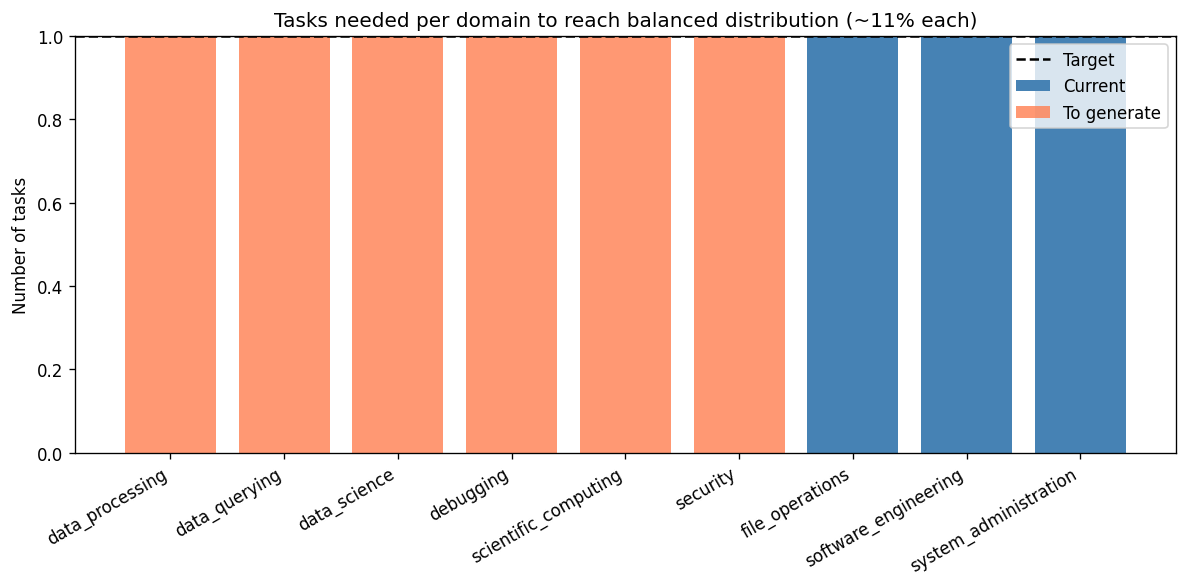

               domain  current  target  to_generate
      data_processing        0       1            1
        data_querying        0       1            1
         data_science        0       1            1
            debugging        0       1            1
 scientific_computing        0       1            1
             security        0       1            1
      file_operations        1       1            0
 software_engineering        1       1            0
system_administration        1       1            0


In [31]:
# gap analysis chart

if len(local_df) > 0:
    TARGET_SHARE = 0.11 #tmax distributes about equally across 9 domains
    TARGET_COUNT = int(TARGET_SHARE * len(local_df))
    domains = sorted(set(CATEGORY_TO_DOMAIN.values()))

    rows = []
    for domain in domains:
        current = (local_df["domain"] == domain).sum()
        to_generate = max(0, TARGET_COUNT - current)
        rows.append({
            "domain": domain,
            "current": current,
            "target": TARGET_COUNT,
            "to_generate": to_generate,
        })

    gap_df = pd.DataFrame(rows).sort_values("to_generate", ascending=False)

    ig, ax = plt.subplots(figsize=(10, 5))
    x = range(len(gap_df))
    ax.bar(x, gap_df["current"], label="Current", color="steelblue")
    ax.bar(x, gap_df["to_generate"], bottom=gap_df["current"], label="To generate", color="coral",
alpha=0.8)
    ax.axhline(y=TARGET_COUNT, color="black", linestyle="--", label="Target")
    ax.set_xticks(list(x))
    ax.set_xticklabels(gap_df["domain"], rotation=30, ha="right")
    ax.set_ylabel("Number of tasks")
    ax.set_title("Tasks needed per domain to reach balanced distribution (~11% each)")
    ax.legend()
    plt.tight_layout()
    plt.show()

    print(gap_df.to_string(index=False))
else:
      print("No local tasks loaded. Run on EC2.")

## 3. Difficulty Distribution - Quantifying the missing intricate tier

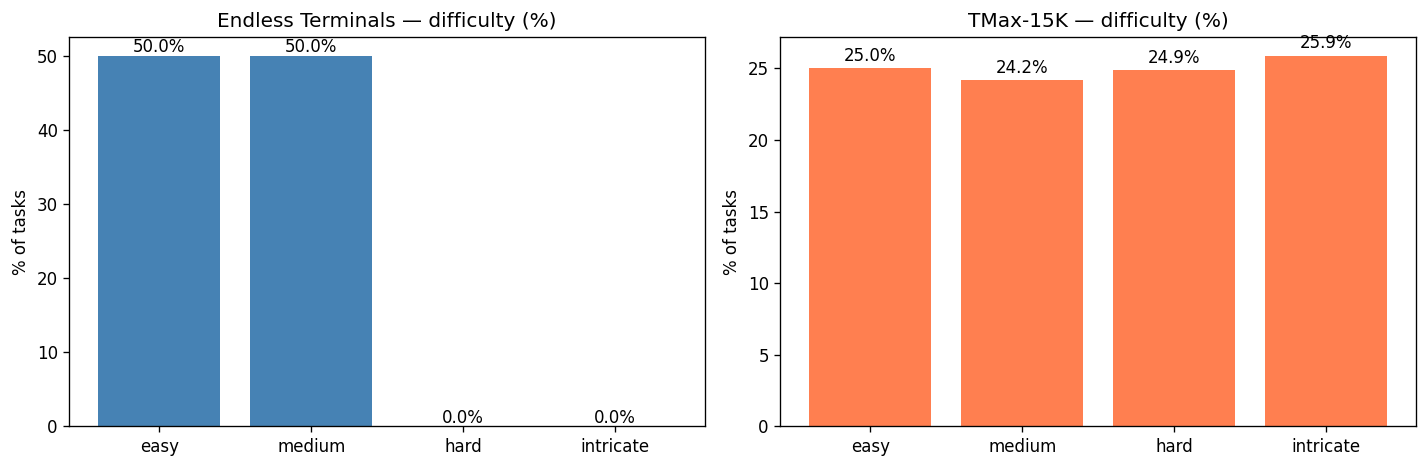

Intricate tasks needed to match TMax (~26%): 2
Current intricate: 0, Target: 2


In [32]:
if len(local_df) > 0:
    difficulty_order = ["easy", "medium", "hard", "intricate"]

    def normalize_tmax_complexity(s):
        s = str(s).lower()
        if "short" in s:
            return "easy"
        elif "moderate" in s:
            return "medium"
        elif "complex" in s:
            return "hard"
        elif "intricate" in s:
            return "intricate"
        return s

    tmax_df["difficulty"] = tmax_df["task_complexity"].apply(normalize_tmax_complexity)

    local_dist = local_df["difficulty"].value_counts().reindex(difficulty_order, fill_value=0)
    tmax_dist = tmax_df["difficulty"].value_counts().reindex(difficulty_order, fill_value=0)

    local_pct = local_dist / len(local_df) * 100
    tmax_pct = tmax_dist / len(tmax_df) * 100

    # How many intricate tasks needed to match TMax's ~26%
    intricate_target = int(0.26 * len(local_df))
    intricate_current = local_dist.get("intricate", 0)
    intricate_gap = intricate_target - intricate_current

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].bar(difficulty_order, local_pct.values, color="steelblue")
    axes[0].set_title("Endless Terminals — difficulty (%)")
    axes[0].set_ylabel("% of tasks")
    for i, v in enumerate(local_pct.values):
        axes[0].text(i, v + 0.5, f"{v:.1f}%", ha="center")

    axes[1].bar(difficulty_order, tmax_pct.values, color="coral")
    axes[1].set_title("TMax-15K — difficulty (%)")
    axes[1].set_ylabel("% of tasks")
    for i, v in enumerate(tmax_pct.values):
        axes[1].text(i, v + 0.5, f"{v:.1f}%", ha="center")

    plt.tight_layout()
    plt.show()

    print(f"Intricate tasks needed to match TMax (~26%): {intricate_gap}")
    print(f"Current intricate: {intricate_current}, Target: {intricate_target}")
else:
    print("No local tasks loaded. Run on EC2.")

## 4. Verifier Quality - Assert count vs. Difficulty

In [34]:
if len(local_df) > 0:
    def count_asserts(test_code):
        return len(re.findall(r'\bassert\b', test_code))

    local_df["assert_count"] = local_df["test_final_state"].apply(count_asserts)
    tmax_df["assert_count"] = tmax_df["test_final_state"].apply(count_asserts)

    fig, ax = plt.subplots(figsize=(9, 4))
    bins = range(0, 60, 2)
    ax.hist(local_df["assert_count"].clip(upper=60), bins=bins, alpha=0.6, label="Endless Terminals",
color="steelblue")
    ax.hist(tmax_df["assert_count"].clip(upper=60), bins=bins, alpha=0.5, label="TMax-15K", color="coral")
    ax.set_xlabel("Assert count per verifier")
    ax.set_ylabel("Number of tasks")
    ax.set_title("Verifier depth: assert count distribution")
    ax.legend()
    plt.tight_layout()
    plt.show()

    print("Mean assert count:")
    print(f"  Endless Terminals: {local_df['assert_count'].mean():.1f}")
    print(f"  TMax-15K:          {tmax_df['assert_count'].mean():.1f}")

    # Assert count by difficulty
    print("\nEndless Terminals — mean asserts by difficulty:")
    print(local_df.groupby("difficulty")["assert_count"].mean().round(1).to_string())
else:
    print("No local tasks loaded. Run on EC2.")

KeyError: 'test_final_state'

## 5. New improvement ideas

## 5. Verifier Coverage Analysis (Idea B)

### 5a. Structural assert category analysis — all 4,929 tasks

Parse each `test_final_state.py` with Python's `ast` module. Classify every assert
into behavioral categories. Compute `structural_score` = fraction of asserts that
check outcomes (process exit codes, stdout, file content) vs. state (file exists,
permissions).

In [ ]:
import ast

ASSERT_CATEGORIES = {
    "file_exists": [
        "os.path.exists", "os.path.isfile", "os.path.isdir",
        "os.path.islink", "Path.exists", ".exists()",
    ],
    "file_content": [
        "open(", ".read(", ".readlines(", "f.read", "content",
    ],
    "permissions": [
        "os.stat", "st_mode", "oct(", "os.access",
    ],
    "process_exit": [
        "subprocess", "returncode", "Popen", "check_call", "check_output",
    ],
    "stdout_output": [
        "stdout", "stderr", "capture_output",
    ],
}

def classify_assert(node_str):
    """Return the first matching category for an assert statement string, or 'other'."""
    for cat, keywords in ASSERT_CATEGORIES.items():
        if any(kw in node_str for kw in keywords):
            return cat
    return "other"

def analyze_verifier(test_code):
    """Parse test_final_state.py source and return per-category assert counts."""
    counts = {cat: 0 for cat in list(ASSERT_CATEGORIES.keys()) + ["other"]}
    try:
        tree = ast.parse(test_code)
    except SyntaxError:
        return counts
    for node in ast.walk(tree):
        if isinstance(node, ast.Assert):
            node_str = ast.unparse(node)
            cat = classify_assert(node_str)
            counts[cat] += 1
    return counts

cat_rows = local_df["test_final_state"].apply(analyze_verifier)
cat_df = pd.DataFrame(list(cat_rows))

for col in cat_df.columns:
    local_df[f"cat_{col}"] = cat_df[col].values

local_df["assert_count_ast"] = cat_df.sum(axis=1)
outcome_cols = ["cat_process_exit", "cat_stdout_output", "cat_file_content"]
local_df["outcome_ratio"] = (
    local_df[outcome_cols].sum(axis=1) / local_df["assert_count_ast"].replace(0, 1)
)
local_df["structural_score"] = local_df["outcome_ratio"]

print("Assert category totals across all tasks:")
for col in [f"cat_{c}" for c in list(ASSERT_CATEGORIES.keys()) + ["other"]]:
    print(f"  {col}: {local_df[col].sum()}")
print(f"\nMean structural_score: {local_df['structural_score'].mean():.3f}")
print(f"Tasks with structural_score == 0 (no outcome asserts): {(local_df['structural_score'] == 0).sum()}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Chart 1: assert category breakdown (stacked bar by difficulty)
cat_cols = [f"cat_{c}" for c in list(ASSERT_CATEGORIES.keys()) + ["other"]]
diff_order = ["easy", "medium", "hard"]
cat_by_diff = local_df[local_df["difficulty"].isin(diff_order)].groupby("difficulty")[cat_cols].mean().reindex(diff_order)

cat_by_diff.plot(kind="bar", stacked=True, ax=axes[0], colormap="tab10")
axes[0].set_title("Mean assert category mix by difficulty")
axes[0].set_xlabel("Difficulty")
axes[0].set_ylabel("Mean assert count")
axes[0].legend(loc="upper right", fontsize=7)
axes[0].tick_params(axis="x", rotation=0)

# Chart 2: structural_score distribution
axes[1].hist(local_df["structural_score"], bins=20, color="steelblue", edgecolor="white")
axes[1].set_title("Structural score distribution (all tasks)")
axes[1].set_xlabel("structural_score (0=only state-checking, 1=all outcome-checking)")
axes[1].set_ylabel("Number of tasks")
axes[1].axvline(local_df["structural_score"].mean(), color="red", linestyle="--",
                label=f"mean={local_df['structural_score'].mean():.2f}")
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nStructural score by difficulty:")
print(local_df[local_df["difficulty"].isin(diff_order)].groupby("difficulty")["structural_score"].describe().round(3))